In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from pathlib import Path
import re
import time
import random

from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Masking, Input, Dense, Dropout, BatchNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

**Load Data and Preprocessing**

In [2]:
# Paths
OUTPUT_DIR = Path("models/raw_keypoints_gait_cycles/")
CYCLES_DIR = Path("D:/PD/PD_latest/dataset/processed_cycles/full/cycles")
METADATA_PATH = Path("D:/PD/PD_latest/dataset/processed_cycles/full/metadata/cycle_metadata.csv")

# Constants
TIMESTEPS = 60
KEYPOINTS_PER_TIMESTEP = 34
NUM_CYCLES = 6

# Create output directories if not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "results").mkdir(exist_ok=True)

In [3]:
# Load metadata
df = pd.read_csv(METADATA_PATH)
print(f"Total cycles: {len(df)} from {df['file_id'].nunique()} files")

# Verify each file has exactly 6 cycles
cycle_counts = df['file_id'].value_counts()
if not cycle_counts.eq(NUM_CYCLES).all():
    bad_files = cycle_counts[cycle_counts != NUM_CYCLES]
    raise ValueError(f"Some files don’t have {NUM_CYCLES} cycles: {bad_files.index.tolist()}")

Total cycles: 240 from 40 files


In [4]:
file_cycle_map = {}

for file_id, group in tqdm(df.groupby('file_id'), desc="Loading & Resampling"):
    group = group.sort_values('cycle_id')
    label = int(group['label'].iloc[0])
    cycles_resampled = []

    for _, row in group.iterrows():
        json_path = CYCLES_DIR / f"{row['file_id']}_cycle_{row['cycle_id']}.json"
        if not json_path.exists():
            raise FileNotFoundError(f"Missing: {json_path}")

        with open(json_path, 'r') as f:
            cyc = json.load(f)
        xy = np.array(cyc['xy'])  # (L, 34)
        L = xy.shape[0]

        # Resample to TIMESTEPS=60
        if L == 0:
            res = np.zeros((TIMESTEPS, KEYPOINTS_PER_TIMESTEP))
        elif L == 1:
            res = np.tile(xy[0], (TIMESTEPS, 1))
        elif L == TIMESTEPS:
            res = xy
        else:
            x_old = np.linspace(0, 1, L)
            x_new = np.linspace(0, 1, TIMESTEPS)
            res = np.column_stack([
                interp1d(x_old, xy[:, i], kind='linear', fill_value="extrapolate")(x_new)
                for i in range(KEYPOINTS_PER_TIMESTEP)
            ])

        cycles_resampled.append(res.astype(np.float32))
    file_cycle_map[file_id] = {
        'cycles': np.stack(cycles_resampled),  # (6, 60, 34)
        'label': label
    }

print(f"Loaded {len(file_cycle_map)} subjects.")

Loading & Resampling: 100%|██████████| 40/40 [00:03<00:00, 10.98it/s]

Loaded 40 subjects.


In [5]:
# Initialize containers
samples = {n: [] for n in range(1, 7)}
labels = {n: [] for n in range(1, 7)}
file_ids = {n: [] for n in range(1, 7)}

print("Building non-overlapping groups...")
for file_id, data in file_cycle_map.items():
    cycles_6 = data['cycles']
    label = data['label']
    for n in range(1, 7):
        groups = [
            cycles_6[start:start + n]
            for start in range(0, 6, n)
            if start + n <= 6
        ]
        for group in groups:
            combined = np.concatenate(group, axis=0)  # (n*60, 34)
            samples[n].append(combined)
            labels[n].append(label)
            file_ids[n].append(file_id)

# Convert to arrays
for n in range(1, 7):
    samples[n] = np.stack(samples[n]).astype(np.float32)
    labels[n] = np.array(labels[n], dtype=int)
    file_ids[n] = np.array(file_ids[n])
    print(f"  {n}-cycle: {len(samples[n])} samples")

Building non-overlapping groups...
  1-cycle: 240 samples
  2-cycle: 120 samples
  3-cycle: 80 samples
  4-cycle: 40 samples
  5-cycle: 40 samples
  6-cycle: 40 samples


**Data Splitting: Train / Validation / Test**

perform **subject-level splitting** to prevent data leakage. All cycles from the same subject go into the same split.

In [6]:
# ============================================
# Subject-Level Data Splitting
# ============================================

# Get unique subjects (file_ids)
unique_files = list(file_cycle_map.keys())
file_labels = np.array([file_cycle_map[f]['label'] for f in unique_files])

print(f"Total subjects: {len(unique_files)}")
print(f"Class distribution:")
for label in [0, 1]:
    count = (file_labels == label).sum()
    print(f"  Class {label}: {count} subjects ({count/len(unique_files)*100:.1f}%)")

# Split ratios
TRAIN_RATIO = 0.70  # 70% for training
VAL_RATIO = 0.15    # 15% for validation
TEST_RATIO = 0.15   # 15% for testing

# First split: separate test set (stratified by label)
train_val_files, test_files, train_val_labels, test_labels = train_test_split(
    unique_files,
    file_labels,
    test_size=TEST_RATIO,
    stratify=file_labels,
    random_state=SEED
)

# Second split: separate train and validation (stratified)
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_files, val_files, train_labels, val_labels = train_test_split(
    train_val_files,
    train_val_labels,
    test_size=val_ratio_adjusted,
    stratify=train_val_labels,
    random_state=SEED
)

# Convert to sets for fast lookup
train_set = set(train_files)
val_set = set(val_files)
test_set = set(test_files)

# Print split summary
print(f"\n{'='*50}")
print("SUBJECT-LEVEL SPLIT SUMMARY")
print(f"{'='*50}")
print(f"Train: {len(train_files)} subjects ({len(train_files)/len(unique_files)*100:.1f}%)")
print(f"  - Class 0: {(train_labels == 0).sum()}")
print(f"  - Class 1: {(train_labels == 1).sum()}")
print(f"\nValidation: {len(val_files)} subjects ({len(val_files)/len(unique_files)*100:.1f}%)")
print(f"  - Class 0: {(val_labels == 0).sum()}")
print(f"  - Class 1: {(val_labels == 1).sum()}")
print(f"\nTest: {len(test_files)} subjects ({len(test_files)/len(unique_files)*100:.1f}%)")
print(f"  - Class 0: {(test_labels == 0).sum()}")
print(f"  - Class 1: {(test_labels == 1).sum()}")
print(f"{'='*50}\n")

# Verify no overlap
assert len(train_set & val_set) == 0, "Train and validation sets overlap!"
assert len(train_set & test_set) == 0, "Train and test sets overlap!"
assert len(val_set & test_set) == 0, "Validation and test sets overlap!"
print("No subject overlap between splits")

Total subjects: 40
Class distribution:
  Class 0: 20 subjects (50.0%)
  Class 1: 20 subjects (50.0%)

SUBJECT-LEVEL SPLIT SUMMARY
Train: 28 subjects (70.0%)
  - Class 0: 14
  - Class 1: 14

Validation: 6 subjects (15.0%)
  - Class 0: 3
  - Class 1: 3

Test: 6 subjects (15.0%)
  - Class 0: 3
  - Class 1: 3

No subject overlap between splits


In [7]:
# ============================================
# Create Datasets for Each Cycle Group (1-6)
# ============================================

def create_split_datasets(samples_dict, labels_dict, file_ids_dict, train_set, val_set, test_set):
    split_data = {}
    
    for n in range(1, 7):
        X = samples_dict[n]
        y = labels_dict[n]
        fids = file_ids_dict[n]
        
        # Create boolean masks
        train_mask = np.array([f in train_set for f in fids])
        val_mask = np.array([f in val_set for f in fids])
        test_mask = np.array([f in test_set for f in fids])
        
        # Split data
        X_train = X[train_mask]
        y_train = y[train_mask]
        
        X_val = X[val_mask]
        y_val = y[val_mask]
        
        X_test = X[test_mask]
        y_test = y[test_mask]
        
        split_data[n] = {
            'X_train': X_train,
            'y_train': y_train,
            'X_val': X_val,
            'y_val': y_val,
            'X_test': X_test,
            'y_test': y_test
        }
        
        print(f"{n}-cycle groups:")
        print(f"  Train: {len(X_train)} samples | Class 0: {(y_train==0).sum()} | Class 1: {(y_train==1).sum()}")
        print(f"  Val:   {len(X_val)} samples | Class 0: {(y_val==0).sum()} | Class 1: {(y_val==1).sum()}")
        print(f"  Test:  {len(X_test)} samples | Class 0: {(y_test==0).sum()} | Class 1: {(y_test==1).sum()}")
        print()
    
    return split_data

# Create splits for all cycle groups
split_data = create_split_datasets(samples, labels, file_ids, train_set, val_set, test_set)

1-cycle groups:
  Train: 168 samples | Class 0: 84 | Class 1: 84
  Val:   36 samples | Class 0: 18 | Class 1: 18
  Test:  36 samples | Class 0: 18 | Class 1: 18

2-cycle groups:
  Train: 84 samples | Class 0: 42 | Class 1: 42
  Val:   18 samples | Class 0: 9 | Class 1: 9
  Test:  18 samples | Class 0: 9 | Class 1: 9

3-cycle groups:
  Train: 56 samples | Class 0: 28 | Class 1: 28
  Val:   12 samples | Class 0: 6 | Class 1: 6
  Test:  12 samples | Class 0: 6 | Class 1: 6

4-cycle groups:
  Train: 28 samples | Class 0: 14 | Class 1: 14
  Val:   6 samples | Class 0: 3 | Class 1: 3
  Test:  6 samples | Class 0: 3 | Class 1: 3

5-cycle groups:
  Train: 28 samples | Class 0: 14 | Class 1: 14
  Val:   6 samples | Class 0: 3 | Class 1: 3
  Test:  6 samples | Class 0: 3 | Class 1: 3

6-cycle groups:
  Train: 28 samples | Class 0: 14 | Class 1: 14
  Val:   6 samples | Class 0: 3 | Class 1: 3
  Test:  6 samples | Class 0: 3 | Class 1: 3



In [ ]:
# ============================================
# Save Test Data for Later Evaluation
# ============================================

# Choose which cycle group to use (typically 6-cycle for full gait analysis)
GROUP_SIZE_FOR_TEST = 6

# Extract test data
X_test_raw = split_data[GROUP_SIZE_FOR_TEST]['X_test']
y_test_final = split_data[GROUP_SIZE_FOR_TEST]['y_test']

# Save test data
np.save('X_test.npy', X_test_raw)
np.save('y_test.npy', y_test_final)

print(f"Test data saved:")
print(f"  - X_test.npy: {X_test_raw.shape}")
print(f"  - y_test.npy: {y_test_final.shape}")
print(f"  - Group size: {GROUP_SIZE_FOR_TEST} cycles")
print(f"  - Class distribution: 0={(y_test_final==0).sum()}, 1={(y_test_final==1).sum()}")

Test data saved:
  - X_test.npy: (6, 360, 34)
  - y_test.npy: (6,)
  - Group size: 6 cycles
  - Class distribution: 0=3, 1=3


**Model Development**

In [9]:
def get_split_indices(fid_array, file_set):
    return np.array([i for i, fid in enumerate(fid_array) if fid in file_set])

def evaluation_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred)
    }

# Define models
from tensorflow.keras.layers import Layer

class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1],1),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros", trainable=True)
        super().build(input_shape)
    def call(self, x):
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)
        return tf.reduce_sum(x * a, axis=1)
    def get_config(self):
        return super().get_config()

def lstm_baseline(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(32, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(16, dropout=0.3, recurrent_dropout=0.2)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def lstm_bidirectional(input_shape):
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(12, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def lstm_simpleatt(input_shape):
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(12, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    att_output = SimpleAttention()(x)
    outputs = Dense(1, activation='sigmoid')(att_output)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def lstm_multiheadatt(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs 
    x = Bidirectional(LSTM(24, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(16, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    attention_output = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    pooled = GlobalAveragePooling1D()(attention_output)
    pooled = Dropout(0.3)(pooled)
    outputs = Dense(1, activation='sigmoid')(pooled)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
    
models = {
    'lstm_baseline': lstm_baseline,
    'lstm_bidirectional': lstm_bidirectional,
    'lstm_simpleatt': lstm_simpleatt,
    'lstm_multiheadatt': lstm_multiheadatt
}

**Model Evaluation**

Cycle Sizes:   0%|          | 0/6 [00:00<?, ?it/s]

Training lstm_baseline on 1-cycle data...


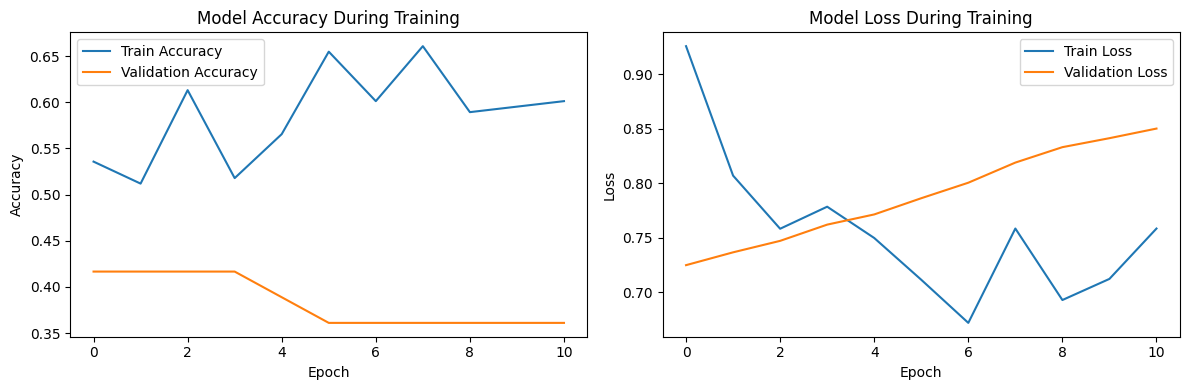

Training lstm_bidirectional on 1-cycle data...


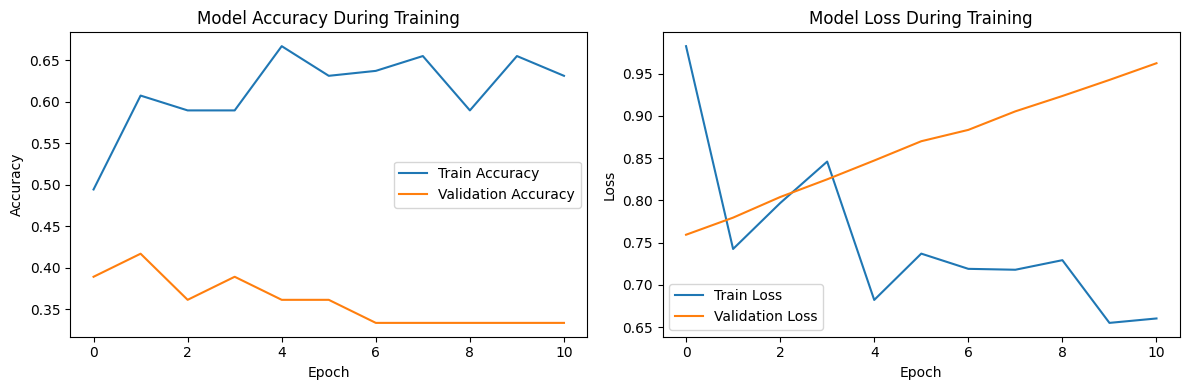

Training lstm_simpleatt on 1-cycle data...



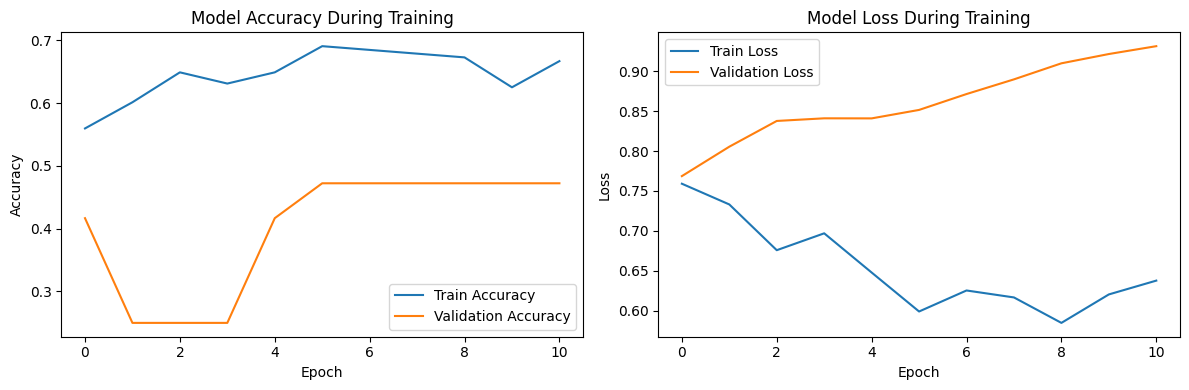

Training lstm_multiheadatt on 1-cycle data...


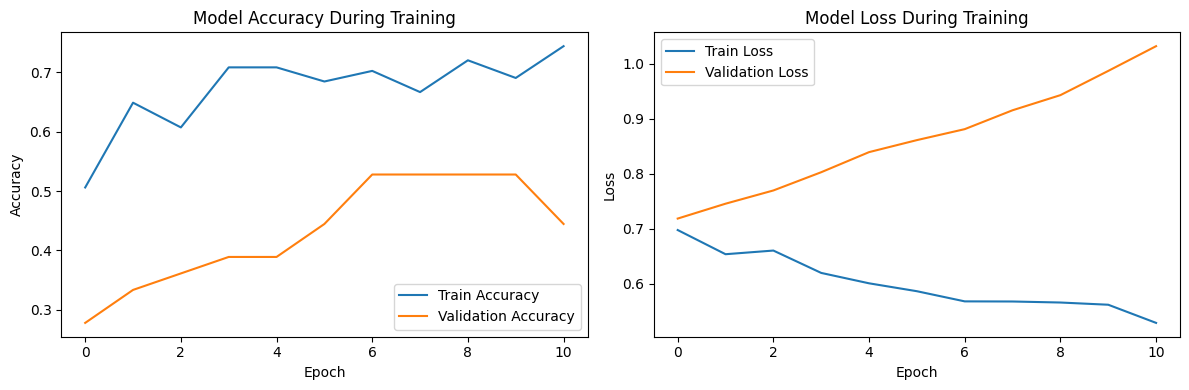

Cycle Sizes:  17%|█▋        | 1/6 [03:39<18:15, 219.04s/it]

Training lstm_baseline on 2-cycle data...


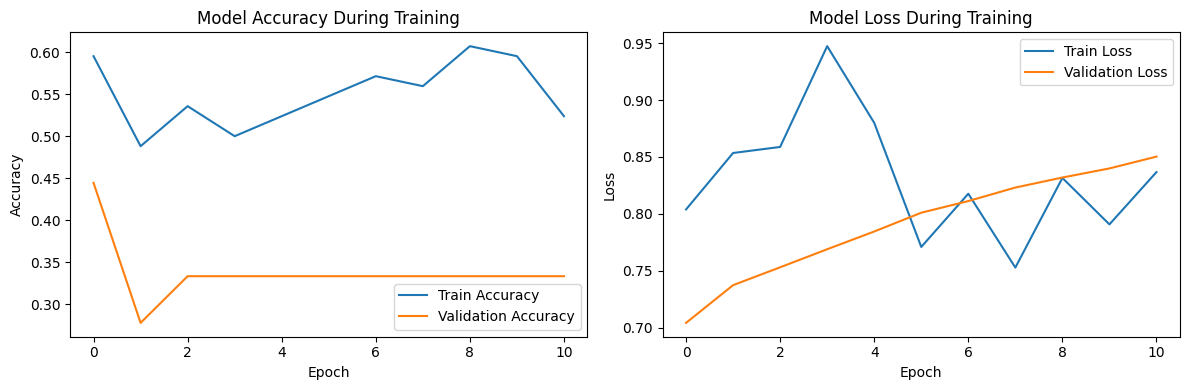

Training lstm_bidirectional on 2-cycle data...


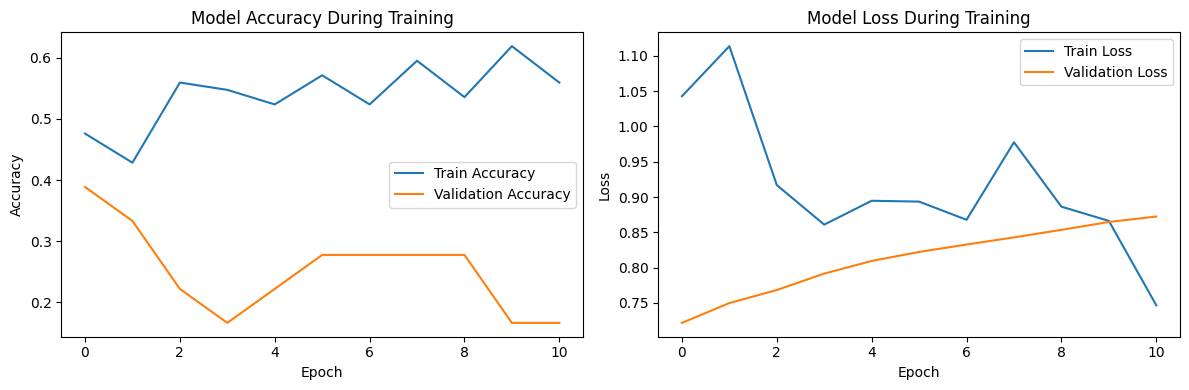

Training lstm_simpleatt on 2-cycle data...


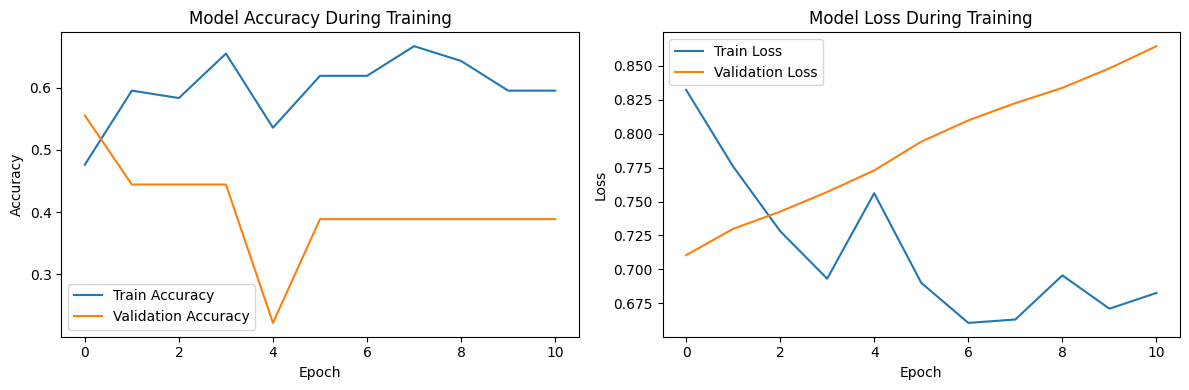

Training lstm_multiheadatt on 2-cycle data...


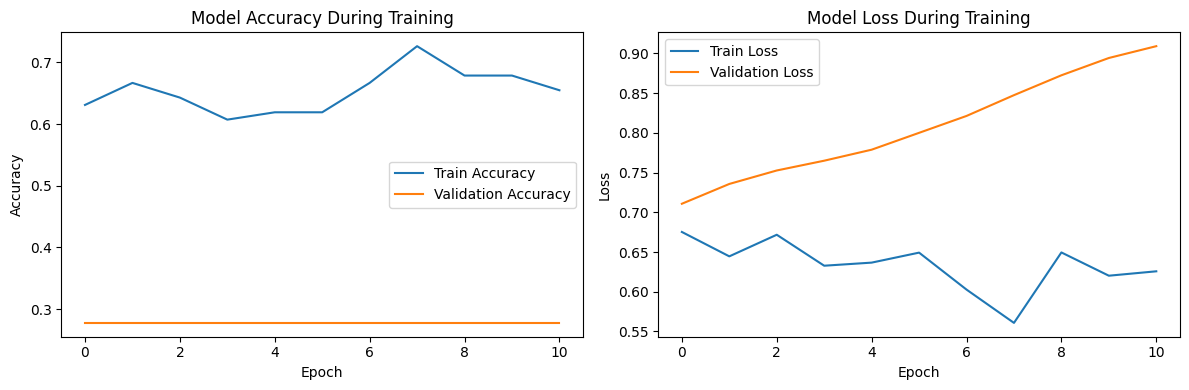

Cycle Sizes:  33%|███▎      | 2/6 [06:28<12:38, 189.71s/it]

Training lstm_baseline on 3-cycle data...


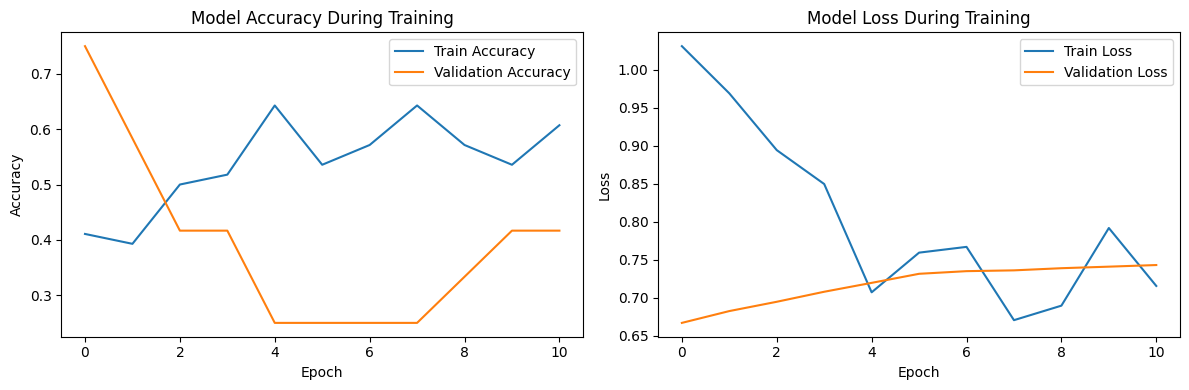

Training lstm_bidirectional on 3-cycle data...


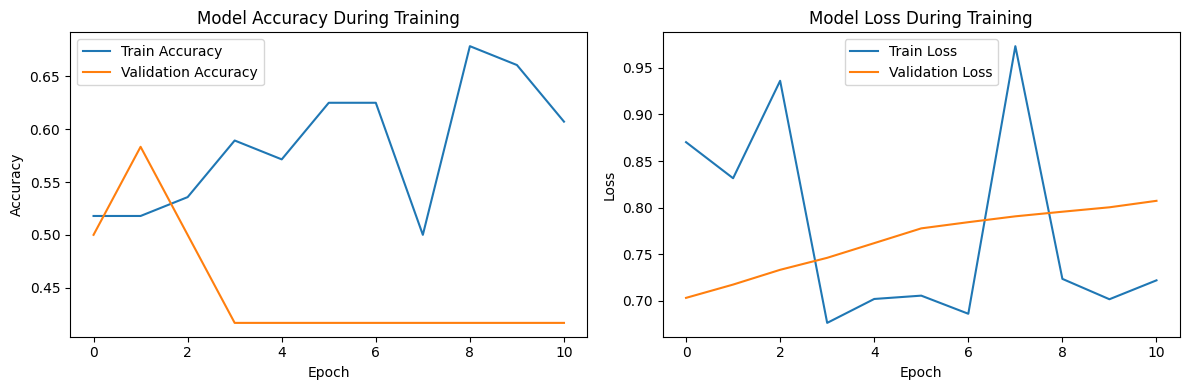

Training lstm_simpleatt on 3-cycle data...


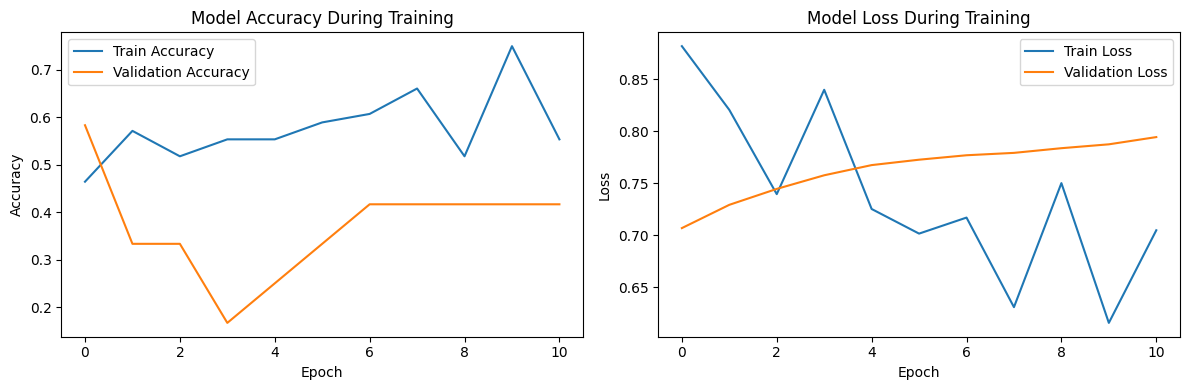

Training lstm_multiheadatt on 3-cycle data...


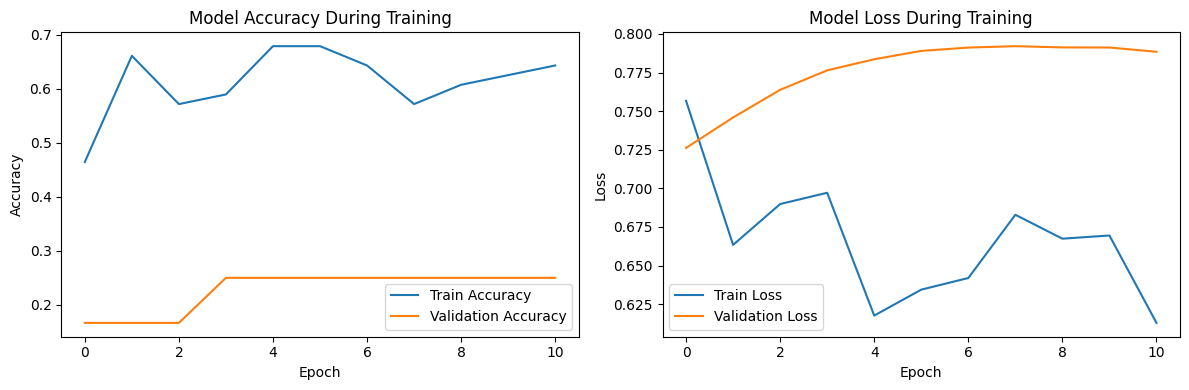

Cycle Sizes:  50%|█████     | 3/6 [08:48<08:21, 167.30s/it]

Training lstm_baseline on 4-cycle data...


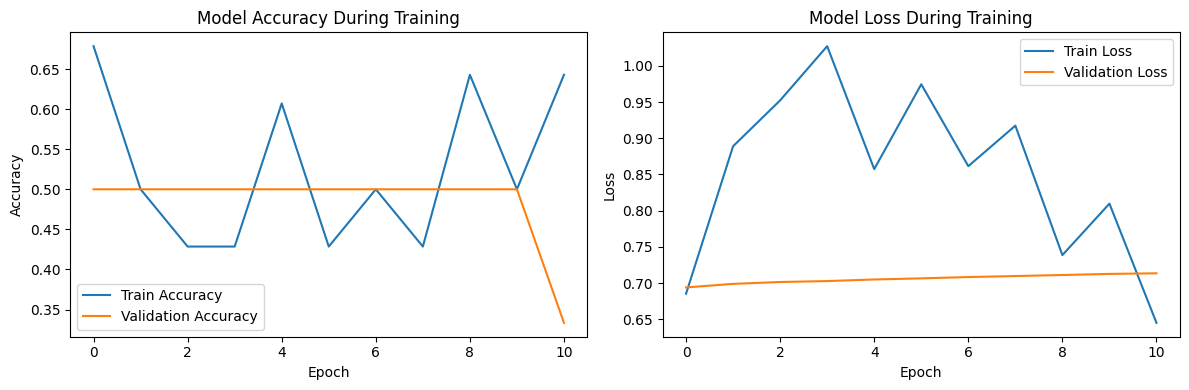

d:\PD\PD_latest\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Training lstm_bidirectional on 4-cycle data...


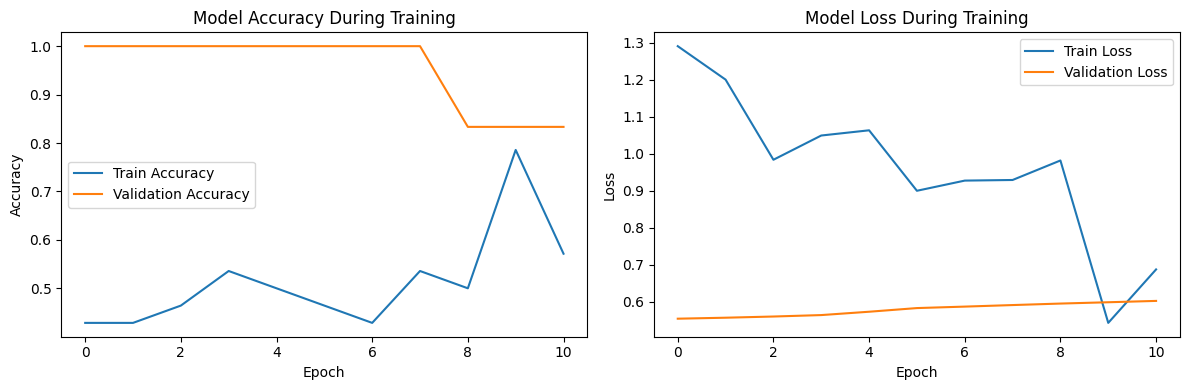

Training lstm_simpleatt on 4-cycle data...


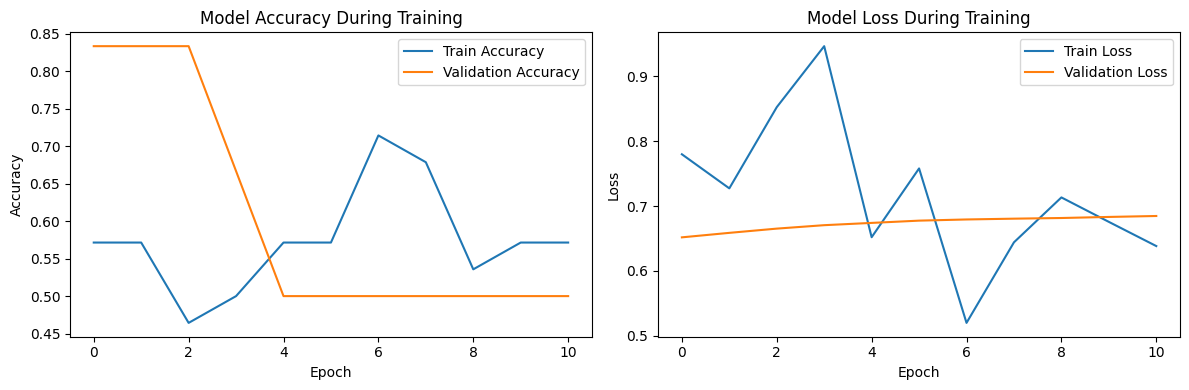

Training lstm_multiheadatt on 4-cycle data...


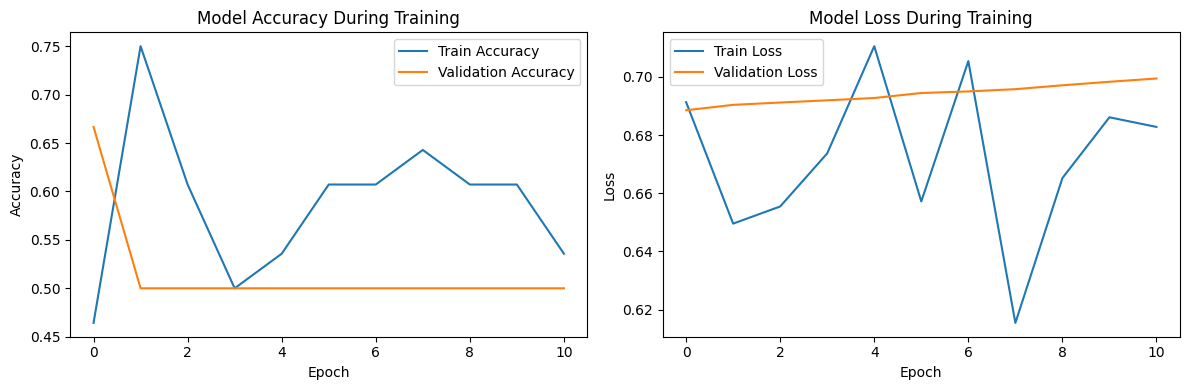

Cycle Sizes:  67%|██████▋   | 4/6 [11:48<05:44, 172.13s/it]

Training lstm_baseline on 5-cycle data...


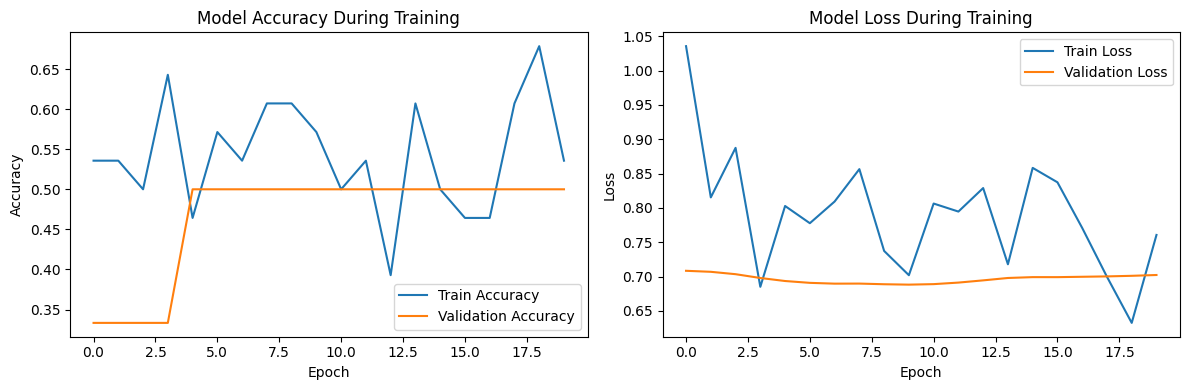

Training lstm_bidirectional on 5-cycle data...


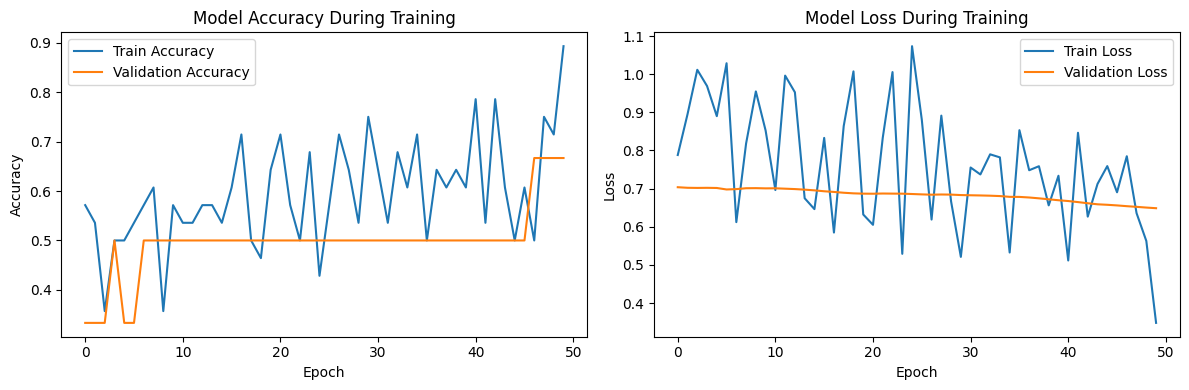

Training lstm_simpleatt on 5-cycle data...


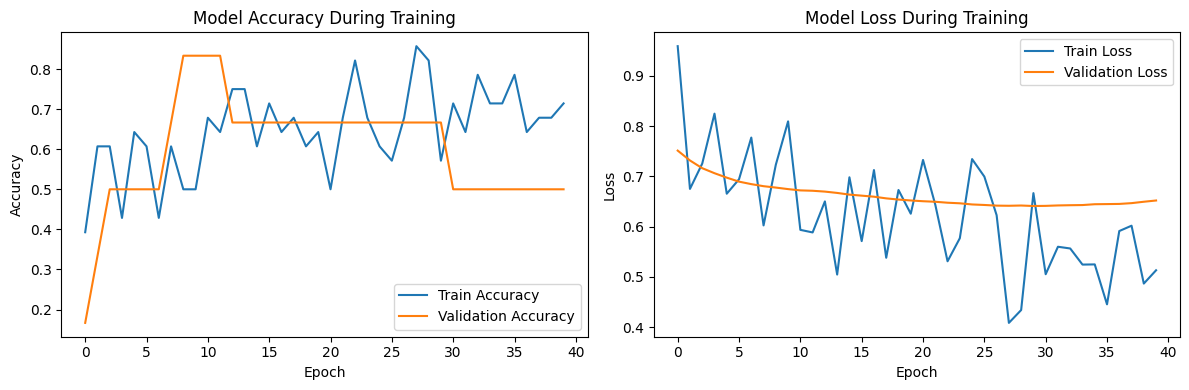

Training lstm_multiheadatt on 5-cycle data...


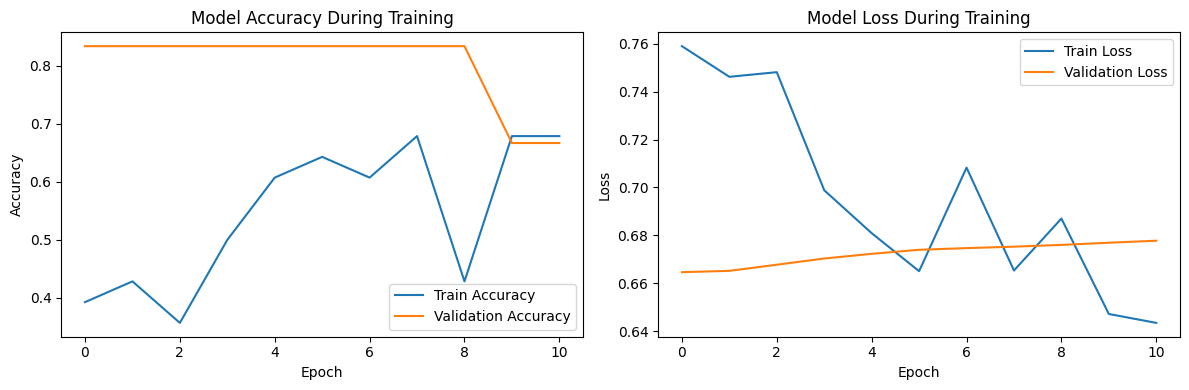

Cycle Sizes:  83%|████████▎ | 5/6 [15:01<02:59, 179.64s/it]

Training lstm_baseline on 6-cycle data...


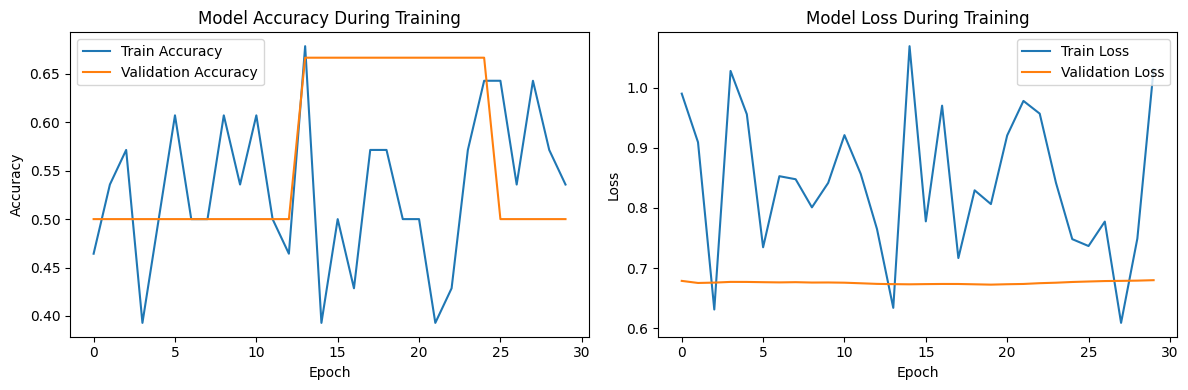

Training lstm_bidirectional on 6-cycle data...


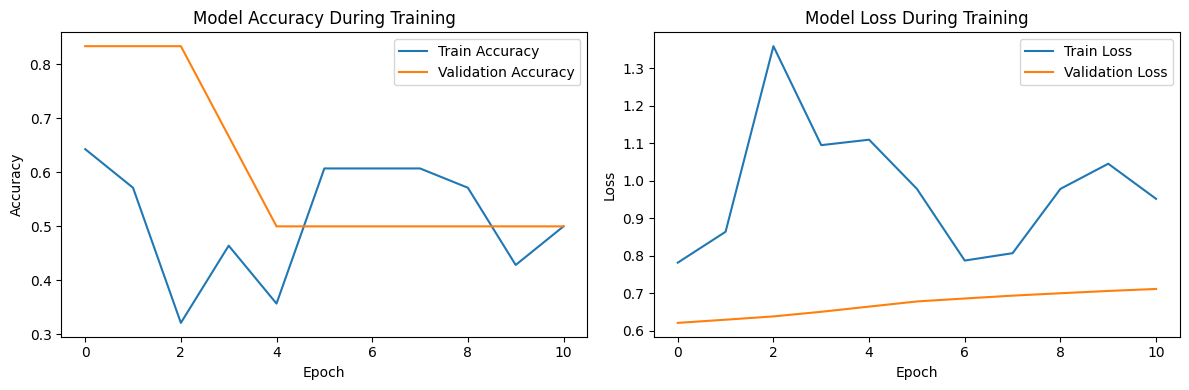

Training lstm_simpleatt on 6-cycle data...


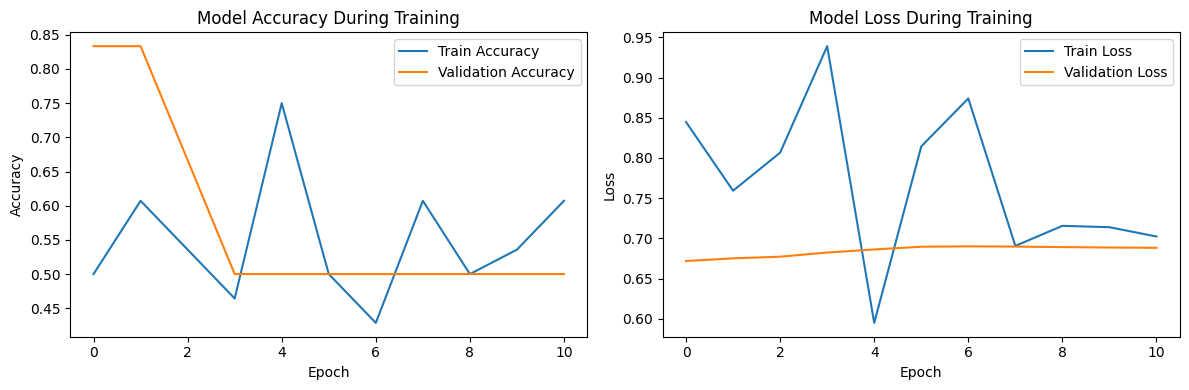

Training lstm_multiheadatt on 6-cycle data...


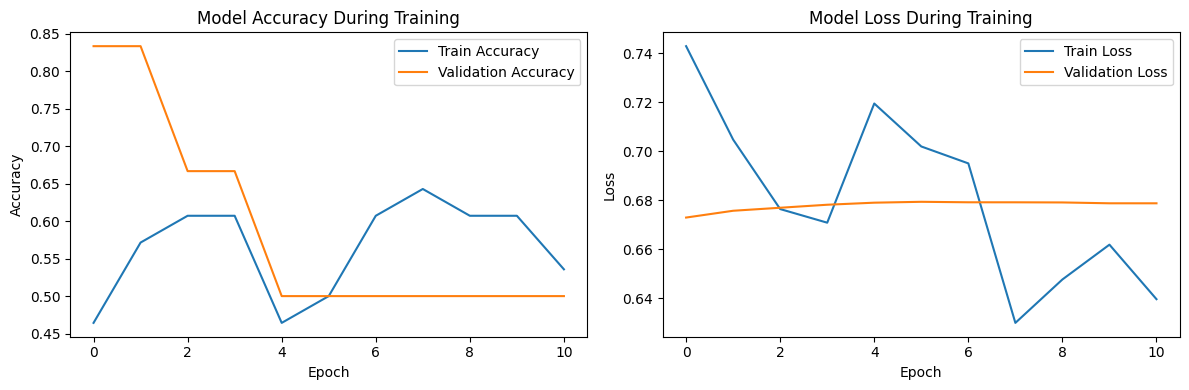

Cycle Sizes: 100%|██████████| 6/6 [17:28<00:00, 174.77s/it]


In [10]:
# Initialize a DataFrame to hold all results
all_results = []

for GROUP_SIZE in tqdm(range(1, 7), desc="Cycle Sizes"):
    train_idx = get_split_indices(file_ids[GROUP_SIZE], train_set)
    val_idx = get_split_indices(file_ids[GROUP_SIZE], val_set)
    X_train_raw = samples[GROUP_SIZE][train_idx]
    X_val_raw = samples[GROUP_SIZE][val_idx]
    y_train = labels[GROUP_SIZE][train_idx]
    y_val = labels[GROUP_SIZE][val_idx]
    
    # Scaling
    scaler = StandardScaler()
    X_train_flat = X_train_raw.reshape(-1, KEYPOINTS_PER_TIMESTEP)
    scaler.fit(X_train_flat)
    X_train = scaler.transform(X_train_flat).reshape(X_train_raw.shape)
    X_val = scaler.transform(X_val_raw.reshape(-1, KEYPOINTS_PER_TIMESTEP)).reshape(X_val_raw.shape)

    expected_seq_len = 60
    X_train = X_train[:, :expected_seq_len, :]
    X_val = X_val[:, :expected_seq_len, :]

    for name, model_fn in models.items():
        print(f"Training {name} on {GROUP_SIZE}-cycle data...")
        input_shape = (X_train.shape[1], KEYPOINTS_PER_TIMESTEP)
        model = model_fn(input_shape)
        start_time = time.time()
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=16,
            callbacks=[
                EarlyStopping(patience=10, restore_best_weights=True),
                ReduceLROnPlateau(factor=0.5, patience=5)
            ],
            verbose=0
        )
        plt.figure(figsize=(12, 4))

        # Plot accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Model Accuracy During Training')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

        # Plot loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss During Training')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.tight_layout()
        plt.show()

        train_time = time.time() - start_time
        y_val_pred = (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()
        metrics = evaluation_metrics(y_val, y_val_pred)
        # Save results for later comparison
        all_results.append({
            'cycle_size': GROUP_SIZE,
            'model_name': name,
            'accuracy': metrics['accuracy'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1_score': metrics['f1_score'],
            'roc_auc': metrics['roc_auc']
        })

In [11]:
# visualize the model architectures using model.summary()
input_shape = (X_train.shape[1], KEYPOINTS_PER_TIMESTEP)  # (timesteps, keypoints)

for model_name, model_func in models.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print('='*60)
    model_instance = model_func(input_shape)  # Build the model
    model_instance.summary()
    print('\n')


Model: lstm_baseline


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 60, 34)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 60, 32)         │         8,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 60, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,921 (46.57 KB)

 Trainable params: 11,825 (46.19 KB)

...

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 60, 34)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_40    │ (None, 60, 48)    │     11,328 │ input_layer_27[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 48)    │        192 │ bidirectional_40… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_66          │ (None, 60, 48)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_41    │ (None, 60, 32)    │      8,320 │ dropout_66[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 32)    │        128 │ bidirectional_41… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_67          │ (None, 60, 32)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 32)    │      4,224 │ dropout_67[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_67[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_69          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │         33 │ dropout_69[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,225 (94.63 KB)

 Trainable params: 24,065 (94.00 KB)

 Non-trainable params: 160 (640.00 B)

In [12]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (28, 60, 34)
y_train shape: (28,)
X_val shape: (6, 60, 34)
y_val shape: (6,)


**Select Best Cycle**

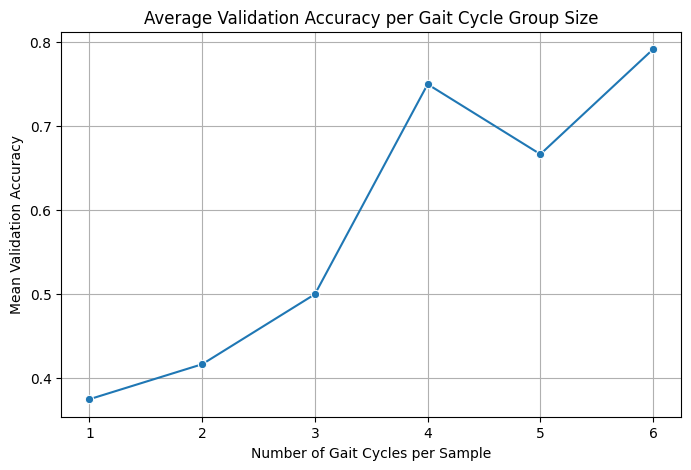

Best cycle size based on validation accuracy: 6


In [13]:
# Convert to DataFrame
results_df = pd.DataFrame(all_results)

# Compute mean accuracy per cycle size
mean_results = results_df.groupby('cycle_size')['accuracy'].mean().reset_index()

# Plot mean accuracy vs cycle size
plt.figure(figsize=(8, 5))
sns.lineplot(data=mean_results, x='cycle_size', y='accuracy', marker='o')
plt.title("Average Validation Accuracy per Gait Cycle Group Size")
plt.xlabel("Number of Gait Cycles per Sample")
plt.ylabel("Mean Validation Accuracy")
plt.grid()
plt.show()

# Select best cycle size
best_cycle_size = mean_results.loc[mean_results['accuracy'].idxmax(), 'cycle_size']
print(f"Best cycle size based on validation accuracy: {best_cycle_size}")

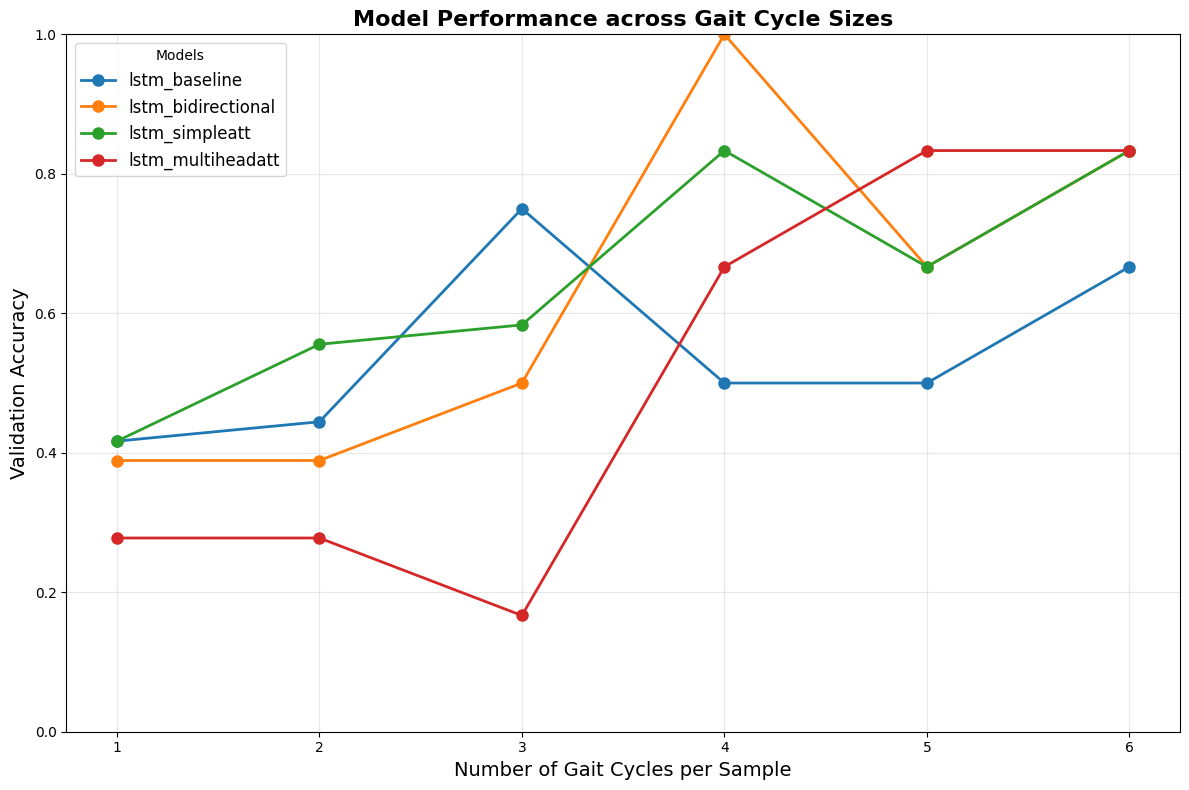

In [14]:
plt.figure(figsize=(12, 8))

# Get unique model names and assign colors
model_names = results_df['model_name'].unique()
colors = sns.color_palette('tab10', n_colors=len(model_names))

# Plot each model's accuracy across cycle sizes
for i, model in enumerate(model_names):
    subset = results_df[results_df['model_name'] == model]
    plt.plot(
        subset['cycle_size'],
        subset['accuracy'],
        marker='o',
        linewidth=2,
        markersize=8,
        color=colors[i],
        label=model
    )

plt.xlabel('Number of Gait Cycles per Sample', fontsize=14)
plt.ylabel('Validation Accuracy', fontsize=14)
plt.title('Model Performance across Gait Cycle Sizes', fontsize=16, fontweight='bold')
plt.xticks(sorted(results_df['cycle_size'].unique()))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title='Models', fontsize=12)
plt.tight_layout()

plt.show()

In [15]:
# Summary table: accuracy vs cycle size
summary = results_df.pivot_table(index='cycle_size', values='accuracy', aggfunc='mean')
print("Validation Accuracy by Cycle Size:")
display(summary)

# Save summary
summary.to_csv(OUTPUT_DIR / "results/summary_accuracy_matrix.csv")

Validation Accuracy by Cycle Size:


,accuracy
cycle_size,
1,0.375000
2,0.416667
3,0.500000
4,0.750000
5,0.666667
6,0.791667


In [16]:
summary = results_df.pivot_table(
    index='cycle_size',
    columns='model_name',
    values='accuracy',
    aggfunc='mean'
).round(4)

print("Validation Accuracy Matrix (Cycle Size × Model):")
display(summary)

summary.to_csv(OUTPUT_DIR / "results/summary_accuracy_matrix.csv")
print("All results exported to 'models/raw_keypoints_gait_cycles/results/'")

Validation Accuracy Matrix (Cycle Size × Model):


model_name,lstm_baseline,lstm_bidirectional,lstm_multiheadatt,lstm_simpleatt
cycle_size,,,,
1,0.4167,0.3889,0.2778,0.4167
2,0.4444,0.3889,0.2778,0.5556
3,0.7500,0.5000,0.1667,0.5833
4,0.5000,1.0000,0.6667,0.8333
5,0.5000,0.6667,0.8333,0.6667
6,0.6667,0.8333,0.8333,0.8333


All results exported to 'models/raw_keypoints_gait_cycles/results/'


In [17]:
# summary of evaluation metrics for each models with average cycles accuracy, preccision, recall, f1_score, roc_auc
metrics_summary = results_df.pivot_table(
    index='model_name',
    values=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'],
    aggfunc='mean'
).round(4)

print("Evaluation Metrics Summary:")
display(metrics_summary)

Evaluation Metrics Summary:


,accuracy,f1_score,precision,recall,roc_auc
model_name,,,,,
lstm_baseline,0.5463,0.4065,0.4141,0.4537,0.5463
lstm_bidirectional,0.6296,0.6062,0.5583,0.6759,0.6296
lstm_multiheadatt,0.5093,0.4823,0.4491,0.5278,0.5093
lstm_simpleatt,0.6481,0.7027,0.6200,0.8241,0.6481


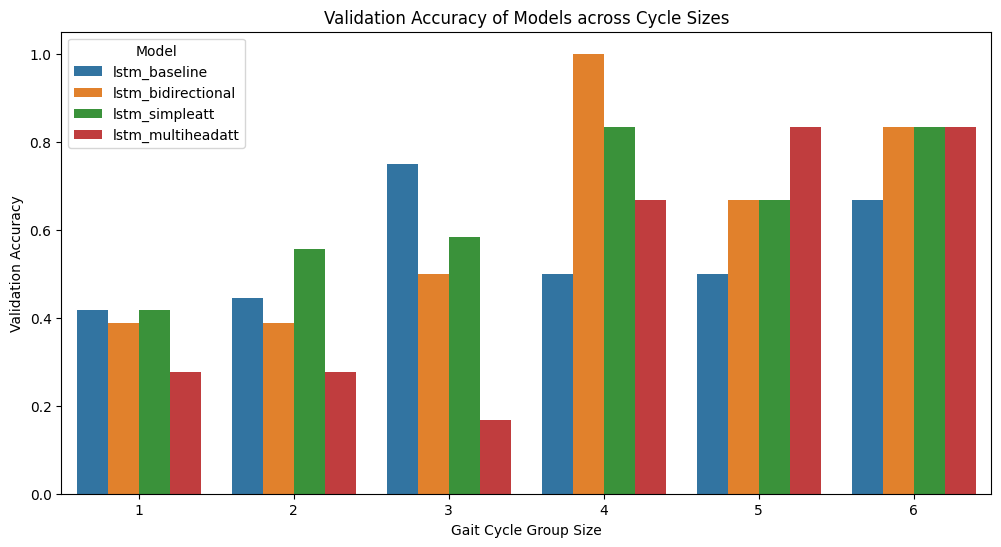

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='cycle_size', y='accuracy', hue='model_name')
plt.title('Validation Accuracy of Models across Cycle Sizes')
plt.xlabel('Gait Cycle Group Size')
plt.ylabel('Validation Accuracy')
plt.legend(title='Model')
plt.show()

**Find Best Model for the Best Cycle Size**

In [19]:
# Filter results for best cycle size
best_cycle_results = results_df[results_df['cycle_size'] == best_cycle_size]
# Find the model with the highest accuracy
best_model_row = best_cycle_results.loc[best_cycle_results['accuracy'].idxmax()]

best_model_name = best_model_row['model_name']
print(f"Best model for cycle size {best_cycle_size}: {best_model_name}")

Best model for cycle size 6: lstm_bidirectional


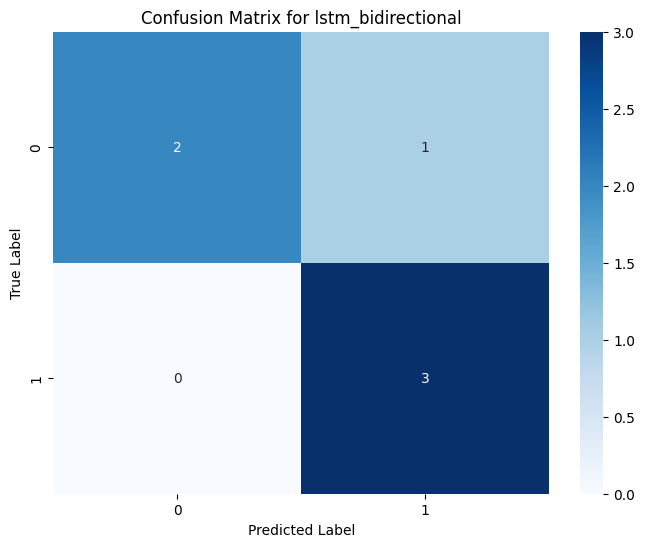

In [20]:
# Confusion matrix visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()

In [21]:
# save the best model and scaler
model_instance = None

# Prefer an actual Keras Model instance if available
for candidate_name in ('best_model', 'model_for_test', 'model'):
	if candidate_name in globals():
		candidate = globals()[candidate_name]
		# check if it's a Keras Model instance
		if isinstance(candidate, Model):
			model_instance = candidate
			break

# If we don't have a model instance, try to recreate it from the factory using best_model_name
if model_instance is None:
	if 'best_model_name' in globals() and best_model_name in models:
		# determine an input shape to instantiate the model
		if 'X_test_scaled' in globals() and X_test_scaled is not None:
			input_shape = (X_test_scaled.shape[1], X_test_scaled.shape[2])
		elif 'X_train' in globals() and X_train is not None:
			input_shape = (X_train.shape[1], X_train.shape[2])
		else:
			input_shape = (TIMESTEPS, KEYPOINTS_PER_TIMESTEP)

		# instantiate model
		model_instance = models[best_model_name](input_shape)

		# attempt to load saved weights if available
		weights_path = OUTPUT_DIR / f"results/{best_model_name}_{best_cycle_size}cycles_weights.h5"
		if weights_path.exists():
			try:
				model_instance.load_weights(str(weights_path))
				print(f"Loaded weights from {weights_path}")
			except Exception as e:
				print(f"Warning: could not load weights from {weights_path}: {e}")
	else:
		raise NameError(
			"No trained model instance found and cannot recreate model. "
			"Ensure you have a Keras model in 'best_model', 'model_for_test' or 'model', "
			"or that 'best_model_name' is set and present in the 'models' dict."
		)

# Save model and scaler (use string paths for compatibility)
save_path = OUTPUT_DIR / f"best_model_{best_model_name}_{best_cycle_size}cycles.h5"
model_instance.save(str(save_path))
joblib.dump(scaler, str(OUTPUT_DIR / f"scaler_{best_cycle_size}cycles.pkl"))
print(f"Saved model to {save_path} and scaler to {OUTPUT_DIR / f'scaler_{best_cycle_size}cycles.pkl'}")

Saved model to models\raw_keypoints_gait_cycles\best_model_lstm_bidirectional_6cycles.h5 and scaler to models\raw_keypoints_gait_cycles\scaler_6cycles.pkl


**Final Evaluation on Test Set**

In [22]:
# Load saved test data
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

try:
    X_test_scaled = scaler.transform(X_test.reshape(-1, KEYPOINTS_PER_TIMESTEP)).reshape(X_test.shape)
except NameError:
    X_test_scaled = X_test
    print("Warning: 'scaler' not found — using raw test data (unscaled).")

# Build your model and load weights as usual
input_shape = (X_test_scaled.shape[1], X_test_scaled.shape[2])
model_for_test = models[best_model_name](input_shape)

weights_path = OUTPUT_DIR / f"results/{best_model_name}_{best_cycle_size}cycles_weights.h5"
if weights_path.exists():
    model_for_test.load_weights(str(weights_path))
else:
    print(f"Note: No saved weights at {weights_path}. Ensure you load trained weights before evaluating.")

# Make predictions
y_test_probs = model_for_test.predict(X_test_scaled, verbose=0)
y_test_pred = (y_test_probs > 0.5).astype(int).flatten()

# Compute metrics
test_metrics = evaluation_metrics(y_test, y_test_pred)
print("Final Model Performance on Test Set:")
for metric_name, value in test_metrics.items():
    print(f"{metric_name}: {value:.4f}")

Note: No saved weights at models\raw_keypoints_gait_cycles\results\lstm_bidirectional_6cycles_weights.h5. Ensure you load trained weights before evaluating.
Final Model Performance on Test Set:
accuracy: 0.6667
precision: 0.6667
recall: 0.6667
f1_score: 0.6667
roc_auc: 0.6667


In [23]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (6, 360, 34)
y_test shape: (6,)


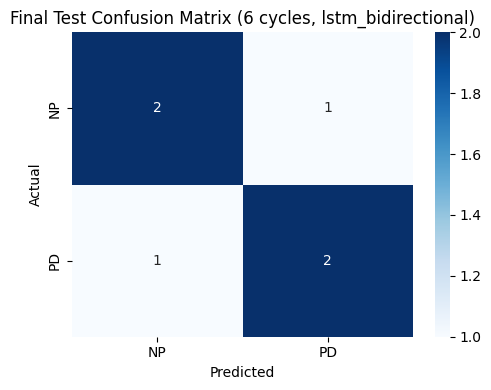

In [24]:
# Confusion matrix visualization
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NP', 'PD'], yticklabels=['NP', 'PD'])
plt.title(f'Final Test Confusion Matrix ({best_cycle_size} cycles, {best_model_name})')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()